# Практика 6: Усложняем GAN — применяем DCGAN

Переходим к сверточным генеративным сетям (`DCGAN`). Заменяем полносвязные слои в генераторе на `ConvTranspose2d`, чтобы увеличивать разрешение изображения поэтапно. В дискриминаторе используем `Conv2d`, `LeakyReLU` и `Dropout`. Обучаем сеть на `MNIST` или `CIFAR-10`, проверяем, как изменение архитектуры влияет на качество изображений. Добавляем слои внимания (`Self-Attention`) в GAN и анализируем влияние на детализацию изображений.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Subset

from torch.cuda.amp import autocast, GradScaler

from tqdm.auto import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

c:\Users\semen\works\NN2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [3]:
image_size = 28
channels = 1

latent_dim = 100

g_features = 64
d_features = 64

batch_size = 128
num_epochs = 40

lr = 0.0002
beta1 = 0.5
beta2 = 0.9

fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

N = 30000
train_dataset = Subset(train_dataset, indices=range(N))

loader_generator = torch.Generator()
loader_generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    generator=loader_generator
)

print("Количество изображений:", len(train_dataset))

Количество изображений: 30000


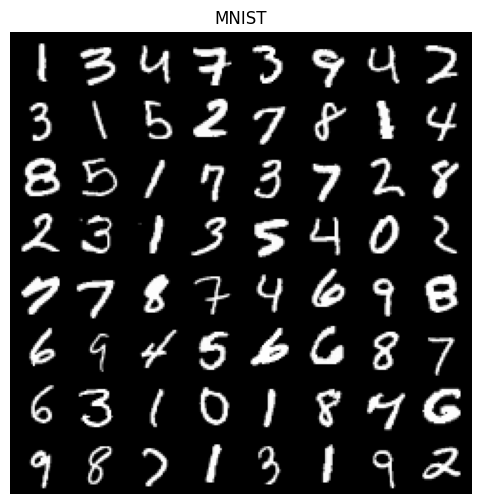

In [5]:
real_batch, _ = next(iter(train_loader))

fig, ax = plt.subplots(figsize=(6, 6))
grid = make_grid(real_batch[:64], nrow=8, normalize=True, value_range=(-1, 1))
ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
ax.axis("off")
ax.set_title("MNIST")
plt.show()

In [6]:
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        proj_query = self.query(x).view(batch_size, -1, height * width).permute(0, 2, 1)
        proj_key = self.key(x).view(batch_size, -1, height * width)
        energy = torch.bmm(proj_query, proj_key)
        attention = self.softmax(energy)

        proj_value = self.value(x).view(batch_size, -1, height * width)
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(batch_size, channels, height, width)

        out = self.gamma * out + x
        return out

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim, g_features=64, channels=1):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, g_features * 4, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(g_features * 4),
            nn.ReLU(True),

            SelfAttention(g_features * 4),

            nn.ConvTranspose2d(g_features * 4, g_features * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(g_features * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(g_features * 2, g_features, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(g_features),
            nn.ReLU(True),

            SelfAttention(g_features),

            nn.Conv2d(g_features, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [8]:
class Discriminator(nn.Module):
    def __init__(self, d_features=64, channels=1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(channels, d_features, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            SelfAttention(d_features),

            nn.Conv2d(d_features, d_features * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(d_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            SelfAttention(d_features * 2),

            nn.Conv2d(d_features * 2, 1, kernel_size=7, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1, 1)

In [9]:
def init_weights(m):
    classname = m.__class__.__name__

    if "Conv" in classname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

    elif "BatchNorm" in classname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

In [10]:
G = Generator(latent_dim=latent_dim, g_features=g_features, channels=channels).to(device)
D = Discriminator(d_features=d_features, channels=channels).to(device)

G.apply(init_weights)
D.apply(init_weights)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout2d(p=0.3, inplace=False)
    (3): SelfAttention(
      (query): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
      (key): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
      (value): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (softmax): Softmax(dim=-1)
    )
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): Dropout2d(p=0.3, inplace=False)
    (8): SelfAttention(
      (query): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (key): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (value): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      (softmax): Softmax(dim=-1)
    

In [11]:
loss_f = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

In [12]:
@torch.no_grad()
def show_generated_images(generator, noise, title="Сгенерированные изображения"):
    generator.eval()
    fake_images = generator(noise).cpu()

    fig, ax = plt.subplots(figsize=(6, 6))
    grid = make_grid(fake_images, nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(title)
    plt.show()

    generator.train()

In [13]:
def train_loop(D,G, num_epochs):
    scaler = GradScaler(enabled=torch.cuda.is_available())
    
    g_losses = []
    d_losses = []
    history_samples = []


    progress_bar = tqdm(range(num_epochs), desc=f"Processing")
    for epoch in progress_bar:
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        t = 0

        for real_images, _ in train_loader:
            t += 1
            progress_bar.set_postfix({
                "T": f"{t} / {len(train_loader)}"
            })
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            real_labels = torch.ones(current_batch_size, 1, device=device)
            fake_labels = torch.zeros(current_batch_size, 1, device=device)


            # 1. Обучение дискриминатора
            optimizer_D.zero_grad()

            real_preds = D(real_images)
            d_loss_real = loss_f(real_preds, real_labels)

            noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)
            fake_images = G(noise).detach()
            fake_preds = D(fake_images)
            d_loss_fake = loss_f(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()


            # 2. Обучение генератора
            optimizer_G.zero_grad()

            noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)

            generated_images = G(noise)
            preds = D(generated_images)

            g_loss = loss_f(preds, real_labels)
                
            g_loss.backward()
            optimizer_G.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        progress_bar.set_postfix({
            "D Loss": f"{avg_d_loss:.4f}",
            "G Loss" : f"{avg_g_loss:.4f}"
        })

        if (epoch + 1) % 5 == 0 or epoch == 0:
            with torch.no_grad():
                samples = G(fixed_noise).cpu()
                history_samples.append((epoch + 1, samples))
            show_generated_images(G, fixed_noise, title=f"Эпоха {epoch + 1}")

    return g_losses, d_losses, history_samples

C:\Users\semen\AppData\Local\Temp\ipykernel_18036\2716176914.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
Processing:   0%|          | 0/40 [01:25<?, ?it/s, D Loss=1.2250, G Loss=1.3636]

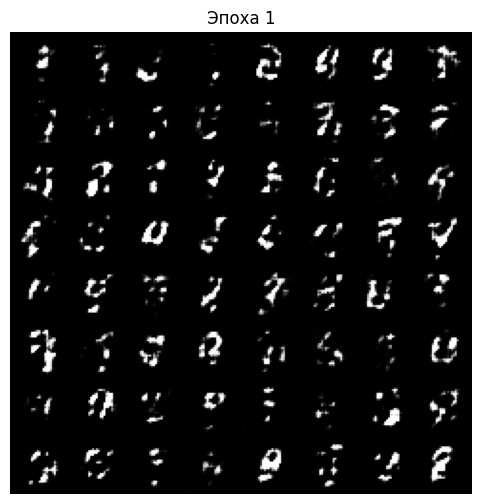

Processing:  10%|█         | 4/40 [07:06<51:13, 85.36s/it, D Loss=1.2989, G Loss=0.9319]

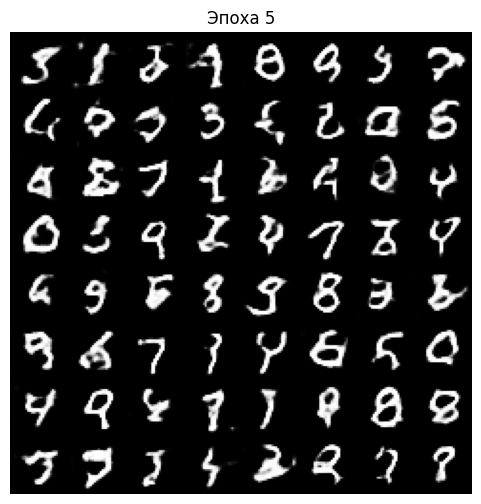

Processing:  22%|██▎       | 9/40 [14:13<44:03, 85.27s/it, D Loss=1.3154, G Loss=0.8715]

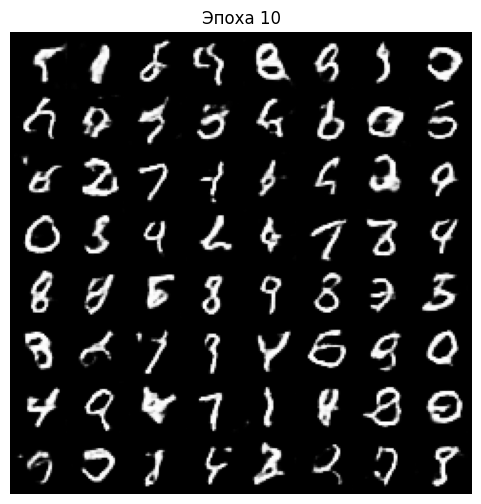

Processing:  35%|███▌      | 14/40 [21:22<37:09, 85.77s/it, D Loss=1.3164, G Loss=0.8477]

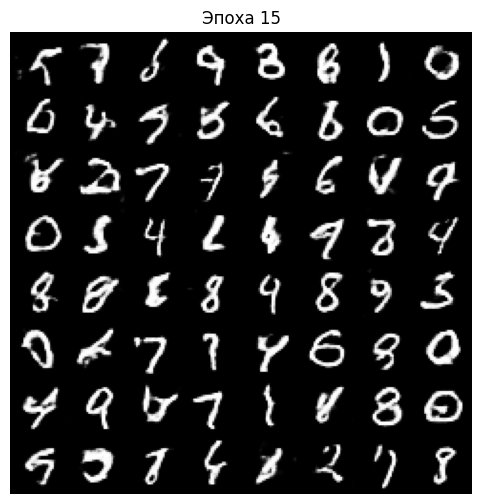

Processing:  48%|████▊     | 19/40 [28:33<30:06, 86.05s/it, D Loss=1.3208, G Loss=0.8439]

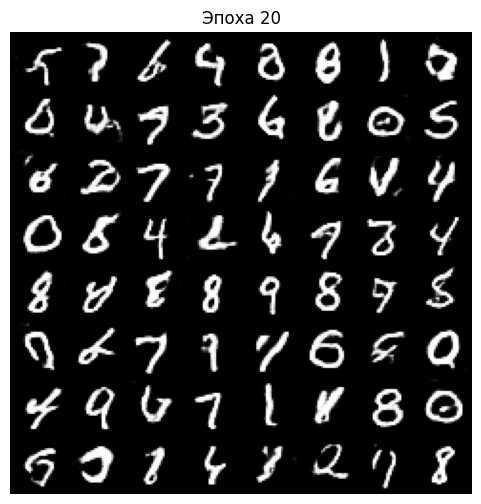

Processing:  60%|██████    | 24/40 [35:44<22:59, 86.20s/it, D Loss=1.3282, G Loss=0.8260]

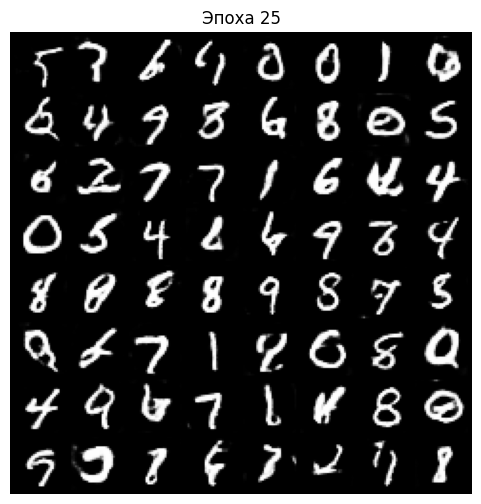

Processing:  72%|███████▎  | 29/40 [42:55<15:47, 86.15s/it, D Loss=1.3320, G Loss=0.8225]

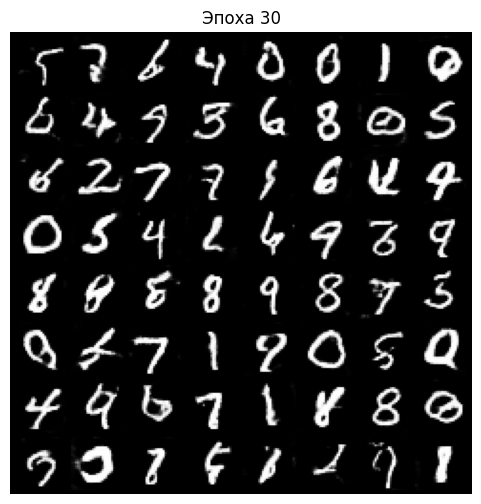

Processing:  85%|████████▌ | 34/40 [50:06<08:37, 86.21s/it, D Loss=1.3268, G Loss=0.8232]

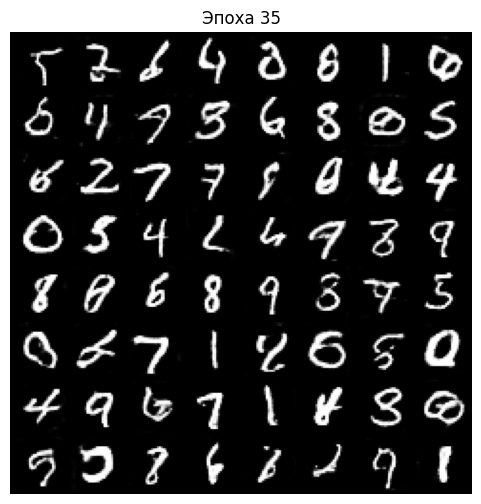

Processing:  98%|█████████▊| 39/40 [59:37<01:26, 86.87s/it, D Loss=1.3131, G Loss=0.8382]

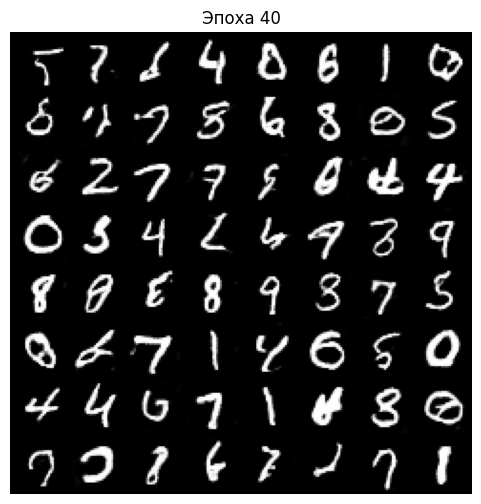

Processing: 100%|██████████| 40/40 [59:38<00:00, 89.45s/it, D Loss=1.3131, G Loss=0.8382] 


In [14]:
g_losses, d_losses, history_samples = train_loop(G= G, D= D, num_epochs = num_epochs)

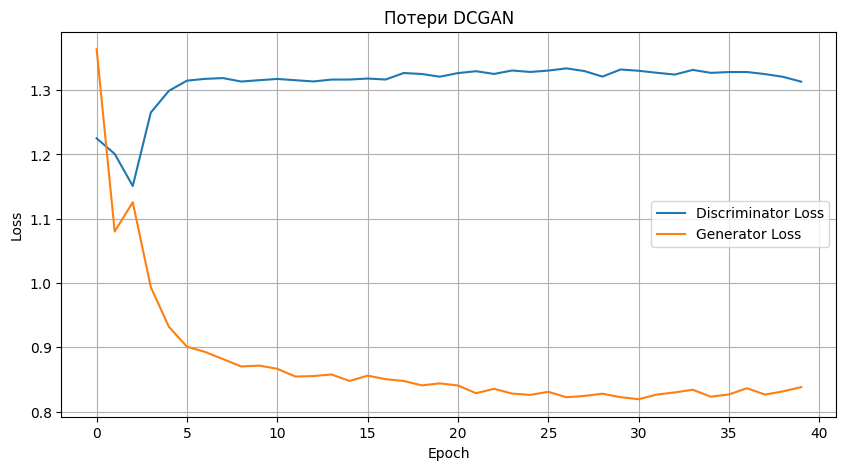

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Потери DCGAN")
plt.legend()
plt.grid(True)
plt.show()

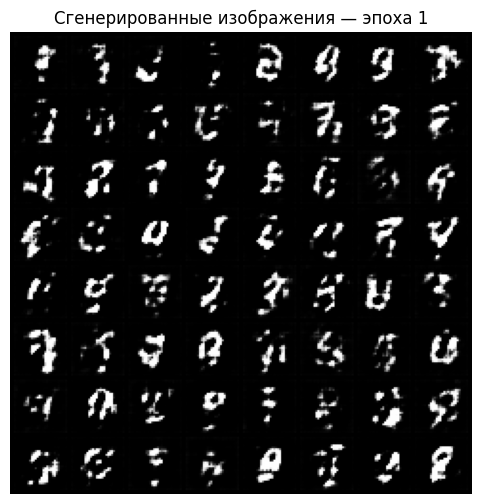

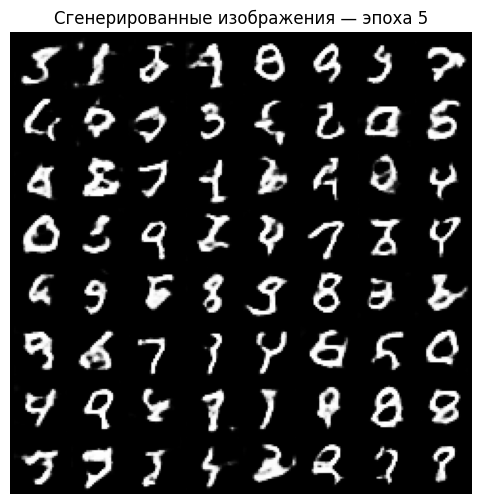

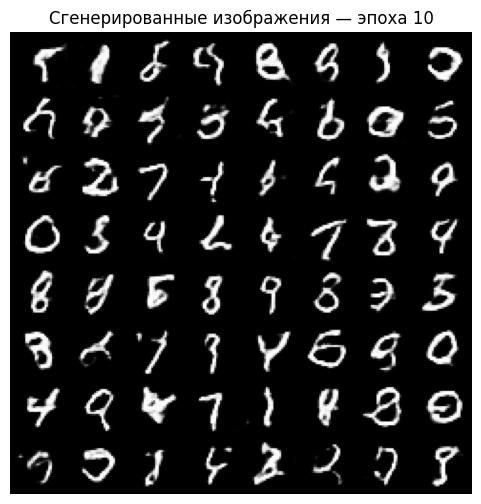

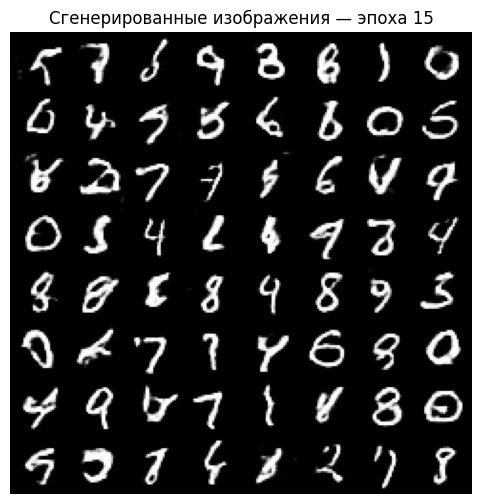

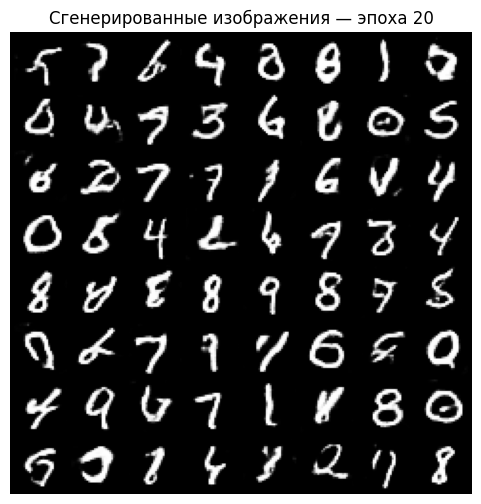

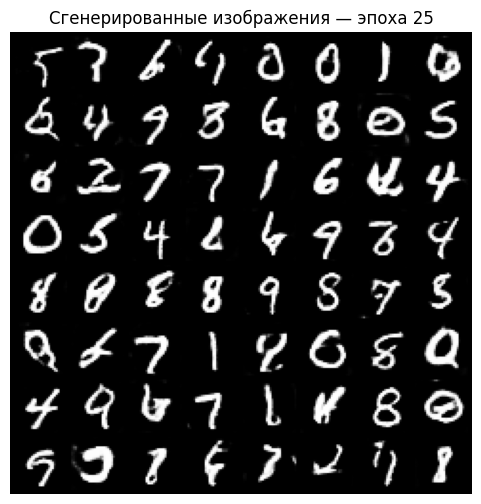

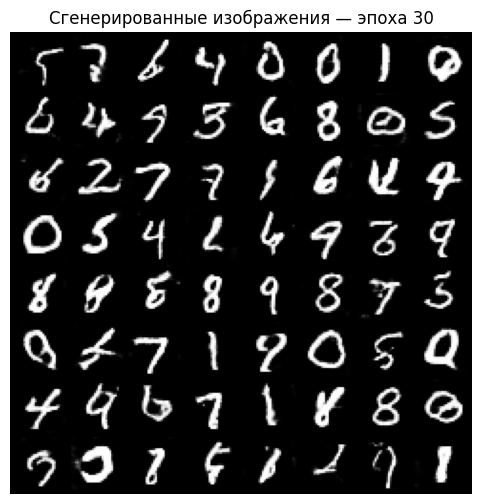

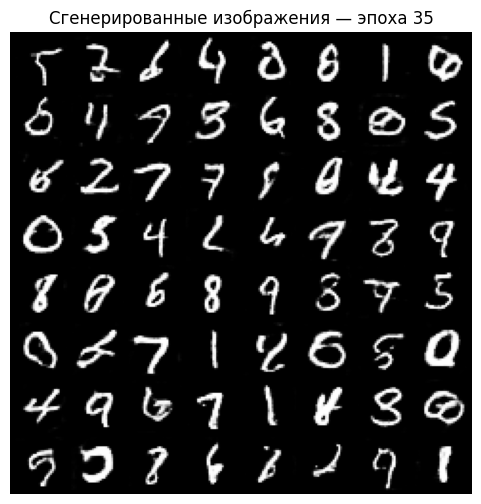

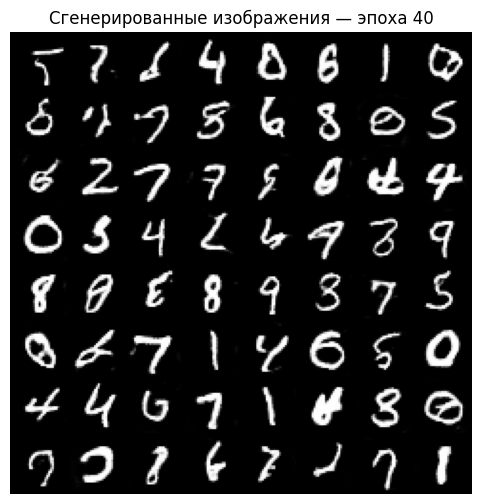

In [16]:
for epoch_num, samples in history_samples:
    fig, ax = plt.subplots(figsize=(6, 6))
    grid = make_grid(samples[:64], nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"Сгенерированные изображения — эпоха {epoch_num}")
    plt.show()

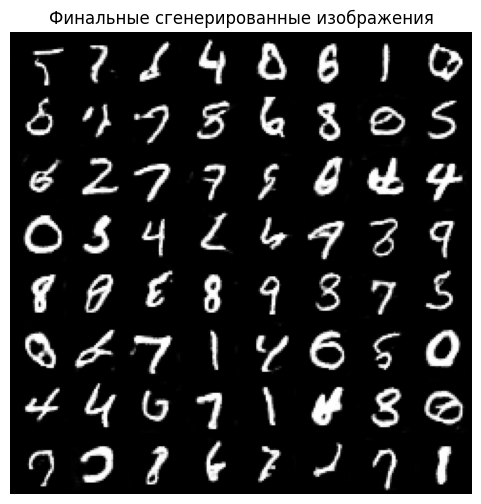

In [18]:
show_generated_images(G, fixed_noise, title="Финальные сгенерированные изображения")